In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
df1 = pd.read_csv('../data/Superstore_Orders_q1.csv')
df2 = pd.read_csv('../data/Superstore_Orders_q2.csv')
df = pd.concat([df1,df2], ignore_index=True)
df['Profit'] = pd.to_numeric(df['Profit'],errors='coerce')

/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_69202/3442050364.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('composite_scorecard.png', dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_69202/3442050364.py:111: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('composite_scorecard.png', dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_69202/3442050364.py:111: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('composite_scorecard.png', dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_69202/3442050364.py:111: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('composite_scorecard.p

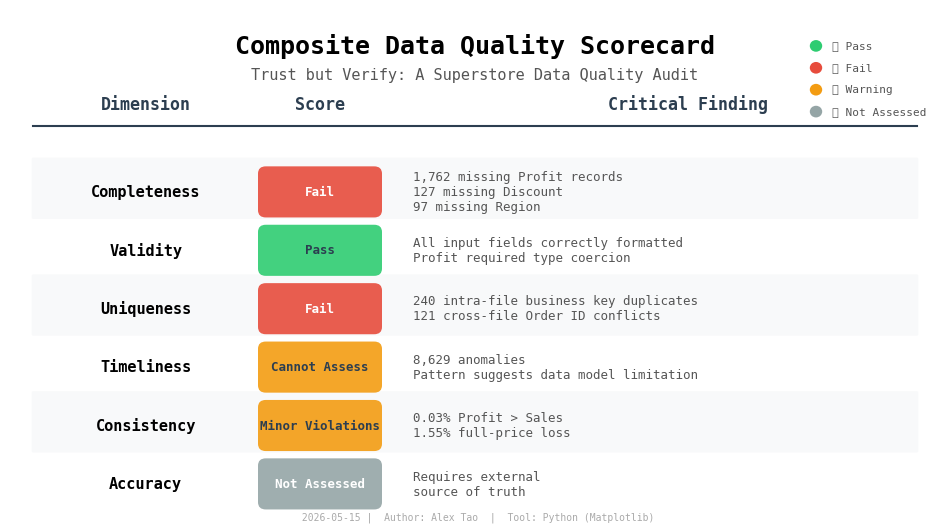

Scorecard saved as 'composite_scorecard.png'


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Data: Your Investigation Board ---
data = [
    ['Completeness', 'Fail', '1,762 missing Profit records\n127 missing Discount\n97 missing Region'],
    ['Validity', 'Pass', 'All input fields correctly formatted\nProfit required type coercion'],
    ['Uniqueness', 'Fail', '240 intra-file business key duplicates\n121 cross-file Order ID conflicts'],
    ['Timeliness', 'Cannot\nAssess', '8,629 anomalies\nPattern suggests data model limitation'],
    ['Consistency', 'Minor\nViolations', '0.03% Profit > Sales\n1.55% full-price loss'],
    ['Accuracy', 'Not\nAssessed', 'Requires external\nsource of truth'],
]

# --- Color Mapping ---
color_map = {
    'Pass': '#2ecc71',           # Green
    'Fail': '#e74c3c',           # Red
    'Cannot\nAssess': '#f39c12', # Yellow/Amber
    'Minor\nViolations': '#f39c12', # Yellow/Amber
    'Not\nAssessed': '#95a5a6',  # Grey
}

# --- Create the Figure ---
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)

# --- Title ---
ax.text(6, 6.5, 'Composite Data Quality Scorecard', fontsize=18, fontweight='bold',
        ha='center', va='center', fontfamily='monospace')
ax.text(6, 6.1, 'Trust but Verify: A Superstore Data Quality Audit', fontsize=11,
        ha='center', va='center', fontfamily='monospace', color='#555555')

# --- Table Structure ---
col_widths = [2.5, 2.0, 7.5]
row_height = 0.8
start_y = 5.3

# Column Headers
headers = ['Dimension', 'Score', 'Critical Finding']
header_x = [0.5, 3.0, 5.0]

for i, (header, x) in enumerate(zip(headers, header_x)):
    ax.text(x + col_widths[i]/2, start_y + 0.4, header, fontsize=12, fontweight='bold',
            ha='center', va='center', fontfamily='monospace', color='#2c3e50')

# Divider line under headers
ax.plot([0.3, 11.7], [start_y + 0.1, start_y + 0.1], color='#2c3e50', linewidth=1.5)

# --- Populate Rows ---
for row_idx, (dimension, score, finding) in enumerate(data):
    y = start_y - (row_idx + 1) * row_height
    
    # Alternating row background
    if row_idx % 2 == 0:
        rect = mpatches.FancyBboxPatch((0.3, y - 0.35), 11.4, row_height,
                                        boxstyle="round,pad=0.02", facecolor='#f8f9fa',
                                        edgecolor='none', zorder=0)
        ax.add_patch(rect)
    
    # Dimension name
    ax.text(0.5 + col_widths[0]/2, y, dimension, fontsize=11, fontweight='bold',
            ha='center', va='center', fontfamily='monospace')
    
    # Score badge
    score_color = color_map.get(score, '#95a5a6')
    score_text = score.replace('\n', ' ')
    
    # Draw colored score box
    badge = mpatches.FancyBboxPatch((3.0 + 0.3, y - 0.25), 1.4, 0.5,
                                     boxstyle="round,pad=0.1", facecolor=score_color,
                                     edgecolor='none', zorder=1, alpha=0.9)
    ax.add_patch(badge)
    
    # Score text (white for dark backgrounds, dark for light)
    text_color = 'white' if score in ['Fail', 'Not\nAssessed'] else '#2c3e50'
    ax.text(3.0 + 1.0, y, score_text, fontsize=9, fontweight='bold',
            ha='center', va='center', fontfamily='monospace', color=text_color, zorder=2)
    
    # Finding text
    ax.text(5.0 + 0.2, y, finding, fontsize=9, ha='left', va='center',
            fontfamily='monospace', color='#555555')

# --- Legend ---
legend_items = [
    ('🟢 Pass', '#2ecc71'),
    ('🔴 Fail', '#e74c3c'),
    ('🟡 Warning', '#f39c12'),
    ('⚪ Not Assessed', '#95a5a6'),
]

legend_x = 10.4
legend_y = 6.5

for i, (label, color) in enumerate(legend_items):
    # Colored circle
    circle = mpatches.Circle((legend_x, legend_y - i * 0.3), 0.08, 
                              facecolor=color, edgecolor='none', zorder=1)
    ax.add_patch(circle)
    # Label text
    ax.text(legend_x + 0.2, legend_y - i * 0.3, label, fontsize=8,
            ha='left', va='center', fontfamily='monospace', color='#555555')
# --- Footer ---
ax.text(6, 0.05, ' 2026-05-15 |  Author: Alex Tao  |  Tool: Python (Matplotlib)',
        fontsize=7, ha='center', va='center', fontfamily='monospace', color='#aaaaaa')

# --- Save & Show ---
plt.subplots_adjust(bottom=0.15)
plt.savefig('composite_scorecard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Scorecard saved as 'composite_scorecard.png'")